# Loading Libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from pathlib import Path

# Loading Data

In [2]:
CLEANED_DATA_DIR = Path("__file__").resolve().parent.parent / "data" / "cleaned"

In [3]:
df = pd.read_csv(CLEANED_DATA_DIR / "cleaned_data.csv")

In [4]:
df.head()

,disasterNumber,declarationDate,incidentType,declarationType,state,fyDeclared,incidentBeginDate,designatedArea_count,ihProgramDeclared,iaProgramDeclared,...,project_count,large_project_count,small_project_count,has_debris,has_emergency,has_roads,has_water,has_buildings,has_utilities,has_parks
0,1239,1998-08-26T00:00:00.000Z,Severe Storm,DR,TX,1998,1998-08-22T00:00:00.000Z,257,0,1,...,276.0,274.0,2.0,True,True,True,True,True,True,True
1,1240,1998-08-27T00:00:00.000Z,Hurricane,DR,NC,1998,1998-08-20T00:00:00.000Z,30,0,1,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,1241,1998-09-04T00:00:00.000Z,Hurricane,DR,FL,1998,1998-09-03T00:00:00.000Z,6,0,1,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,1242,1998-09-04T00:00:00.000Z,Hurricane,DR,VA,1998,1998-08-25T00:00:00.000Z,5,0,1,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,1243,1998-09-04T00:00:00.000Z,Hurricane,DR,SC,1998,1998-08-25T00:00:00.000Z,1,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3940 entries, 0 to 3939
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   disasterNumber              3940 non-null   int64  
 1   declarationDate             3940 non-null   object 
 2   incidentType                3940 non-null   object 
 3   declarationType             3940 non-null   object 
 4   state                       3940 non-null   object 
 5   fyDeclared                  3940 non-null   int64  
 6   incidentBeginDate           3940 non-null   object 
 7   designatedArea_count        3940 non-null   int64  
 8   ihProgramDeclared           3940 non-null   int64  
 9   iaProgramDeclared           3940 non-null   int64  
 10  paProgramDeclared           3940 non-null   int64  
 11  hmProgramDeclared           3940 non-null   int64  
 12  incident_duration_days      3940 non-null   float64
 13  is_ongoing                  3940 

In [6]:
for cols in df.columns:
    if "date" in cols.lower():
        df[cols] = pd.to_datetime(df[cols], errors="coerce")

In [7]:
for column in df.columns:
    if df[column].dtype == "object":
        print(f"Column: {column}")
        print(df[column].unique())
        print("\n")

Column: incidentType
['Severe Storm' 'Hurricane' 'Mud/Landslide' 'Flood' 'Severe Ice Storm'
 'Freezing' 'Tornado' 'Snowstorm' 'Fire' 'Earthquake' 'Coastal Storm'
 'Terrorist' 'Typhoon' 'Dam/Levee Break' 'Tsunami' 'Drought' 'Other'
 'Toxic Substances' 'Human Cause' 'Fishing Losses' 'Chemical' 'Biological'
 'Tropical Storm' 'Winter Storm' 'Volcanic Eruption' 'Straight-Line Winds'
 'Tropical Depression']


Column: declarationType
['DR' 'FM' 'EM']


Column: state
['TX' 'NC' 'FL' 'VA' 'SC' 'NY' 'LA' 'PR' 'VI' 'AL' 'MS' 'WA' 'MO' 'KS'
 'TN' 'ME' 'AR' 'CA' 'WY' 'GA' 'OK' 'CO' 'IA' 'IL' 'ND' 'SD' 'NV' 'MN'
 'WI' 'UT' 'NE' 'PA' 'NJ' 'DE' 'NM' 'CT' 'MD' 'AZ' 'NH' 'VT' 'KY' 'AK'
 'WV' 'OH' 'DC' 'MT' 'ID' 'MI' 'HI' 'MA' 'GU' 'OR' 'FM' 'IN' 'MP' 'AS'
 'RI']


Column: has_debris
['True' '0' 'False']


Column: has_emergency
['True' '0' 'False']


Column: has_roads
['True' '0' 'False']


Column: has_water
['True' '0' 'False']


Column: has_buildings
['True' '0' 'False']


Column: has_utilities
['True'

In [8]:
for column in df.columns:
    if "has" in column.lower():
        df[column] = df[column].replace({'0': False, '1': True}).astype(bool)

In [9]:
for column in df.columns:
    if "has" in column.lower():
        df[column] = df[column].astype(int)

In [10]:
df.head()

,disasterNumber,declarationDate,incidentType,declarationType,state,fyDeclared,incidentBeginDate,designatedArea_count,ihProgramDeclared,iaProgramDeclared,...,project_count,large_project_count,small_project_count,has_debris,has_emergency,has_roads,has_water,has_buildings,has_utilities,has_parks
0,1239,1998-08-26 00:00:00+00:00,Severe Storm,DR,TX,1998,1998-08-22 00:00:00+00:00,257,0,1,...,276.0,274.0,2.0,1,1,1,1,1,1,1
1,1240,1998-08-27 00:00:00+00:00,Hurricane,DR,NC,1998,1998-08-20 00:00:00+00:00,30,0,1,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,1241,1998-09-04 00:00:00+00:00,Hurricane,DR,FL,1998,1998-09-03 00:00:00+00:00,6,0,1,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,1242,1998-09-04 00:00:00+00:00,Hurricane,DR,VA,1998,1998-08-25 00:00:00+00:00,5,0,1,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,1243,1998-09-04 00:00:00+00:00,Hurricane,DR,SC,1998,1998-08-25 00:00:00+00:00,1,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [11]:
df.columns

Index(['disasterNumber', 'declarationDate', 'incidentType', 'declarationType',
       'state', 'fyDeclared', 'incidentBeginDate', 'designatedArea_count',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'incident_duration_days', 'is_ongoing',
       'totalAmountIhpApproved', 'totalAmountHaApproved',
       'totalAmountOnaApproved', 'totalObligatedAmountPa',
       'totalObligatedAmountCatAb', 'totalObligatedAmountCatC2g',
       'totalObligatedAmountHmgp', 'total_disaster_cost', 'total_obligated',
       'federal_obligated', 'avg_project_cost', 'applicant_count',
       'project_count', 'large_project_count', 'small_project_count',
       'has_debris', 'has_emergency', 'has_roads', 'has_water',
       'has_buildings', 'has_utilities', 'has_parks'],
      dtype='object')

# EDA

## Categorical EDA

In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['disasterNumber', 'declarationDate', 'incidentBeginDate', 'incidentEndDate']]
print(cat_cols)

print("=== ANOVA: Category vs total_disaster_cost ===")
for col in cat_cols:
    groups = [group['total_disaster_cost'].values for _, group in df.groupby(col)]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"{col}: F={f_stat:.2f}, p={p_value:.4f} {'✓ significant' if p_value < 0.05 else '✗ not significant'}")


['incidentType', 'declarationType', 'state']
=== ANOVA: Category vs total_disaster_cost ===
incidentType: F=4.68, p=0.0000 ✓ significant
declarationType: F=19.79, p=0.0000 ✓ significant
state: F=2.03, p=0.0000 ✓ significant


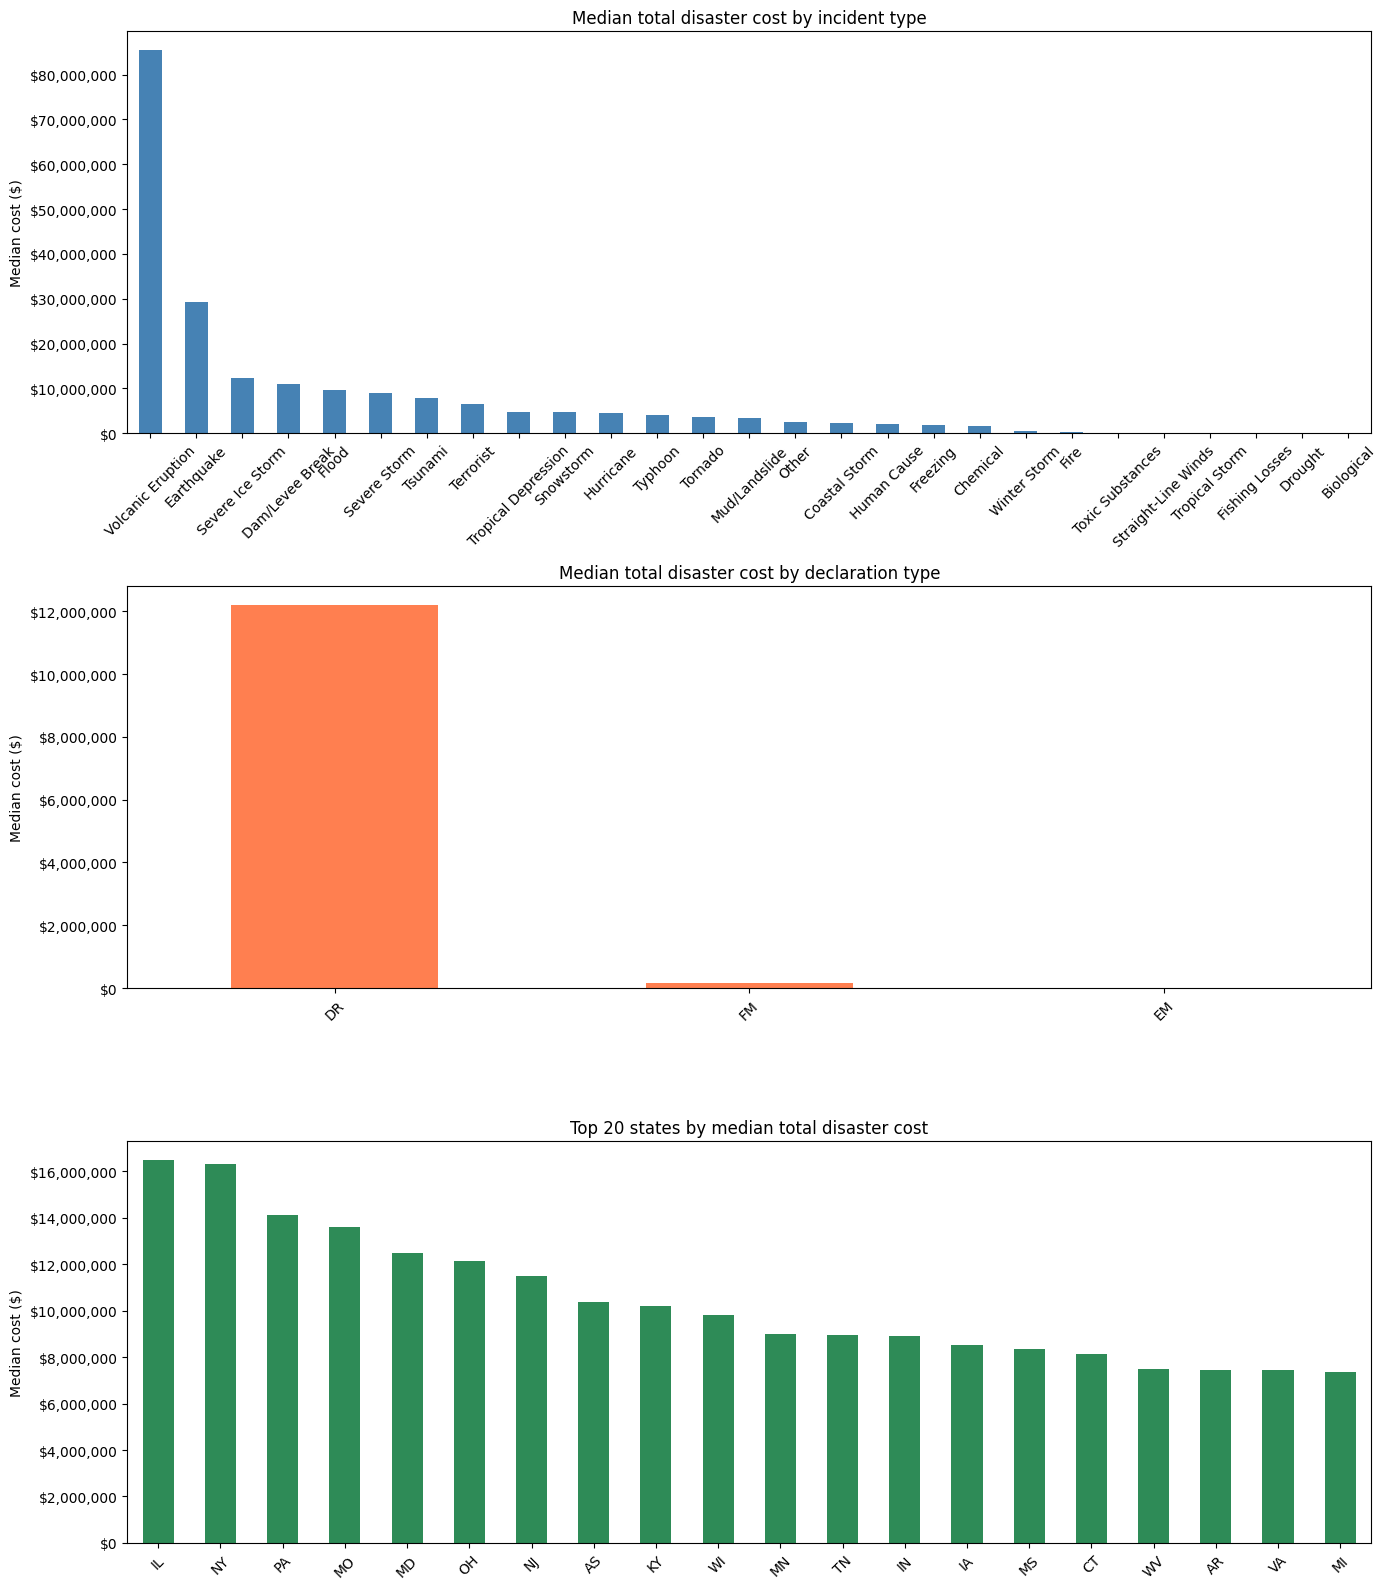

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# 1. Median cost by incidentType
incident_medians = (df.groupby('incidentType')['total_disaster_cost']
                    .median()
                    .sort_values(ascending=False))

incident_medians.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Median total disaster cost by incident type')
axes[0].set_ylabel('Median cost ($)')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)


decl_medians = (df.groupby('declarationType')['total_disaster_cost']
                .median()
                .sort_values(ascending=False))

decl_medians.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Median total disaster cost by declaration type')
axes[1].set_ylabel('Median cost ($)')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)


state_medians = (df.groupby('state')['total_disaster_cost']
                 .median()
                 .sort_values(ascending=False)
                 .head(20))

state_medians.plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('Top 20 states by median total disaster cost')
axes[2].set_ylabel('Median cost ($)')
axes[2].set_xlabel('')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [40]:
print(df['declarationType'].value_counts())

declarationType
DR    1671
FM    1631
EM     638
Name: count, dtype: int64


In [41]:
# What are FM declarations actually for?
print(df[df['declarationType'] == 'FM']['incidentType'].value_counts())

# And their actual cost distribution
print(df[df['declarationType'] == 'FM']['total_disaster_cost'].describe())

incidentType
Fire    1631
Name: count, dtype: int64
count    1.631000e+03
mean     1.746447e+06
std      5.779664e+06
min      0.000000e+00
25%      0.000000e+00
50%      1.741553e+05
75%      1.285140e+06
max      1.117160e+08
Name: total_disaster_cost, dtype: float64


In [43]:
# Confirm by comparing Fire costs across declaration types
print(df[df['incidentType'] == 'Fire'].groupby('declarationType')['total_disaster_cost'].describe())

                  count          mean           std      min         25%  \
declarationType                                                            
DR                 55.0  2.429591e+08  7.393726e+08  13056.0  4605726.63   
EM                 25.0  1.839216e+07  5.183220e+07      0.0        0.00   
FM               1631.0  1.746447e+06  5.779664e+06      0.0        0.00   

                         50%           75%           max  
declarationType                                           
DR               13554085.90  1.919443e+08  4.997195e+09  
EM                      0.00  4.478262e+06  2.462301e+08  
FM                 174155.26  1.285140e+06  1.117160e+08  


In [44]:
df['is_fire_management'] = (df['declarationType'] == 'FM').astype(int)

## Numerical EDA

totalObligatedAmountPa        0.992061
total_obligated               0.991560
federal_obligated             0.991299
totalObligatedAmountCatC2g    0.851278
large_project_count           0.758860
totalObligatedAmountHmgp      0.700320
totalObligatedAmountCatAb     0.698172
totalAmountOnaApproved        0.607419
totalAmountIhpApproved        0.582971
totalAmountHaApproved         0.535152
avg_project_cost              0.526700
project_count                 0.480704
small_project_count           0.357890
applicant_count               0.307726
ihProgramDeclared             0.180839
designatedArea_count          0.147482
log_cost                      0.134982
incident_duration_days        0.111870
has_debris                    0.094661
has_emergency                 0.094661
has_roads                     0.094661
has_water                     0.094661
has_buildings                 0.094661
has_utilities                 0.094661
has_parks                     0.094661
hmProgramDeclared        

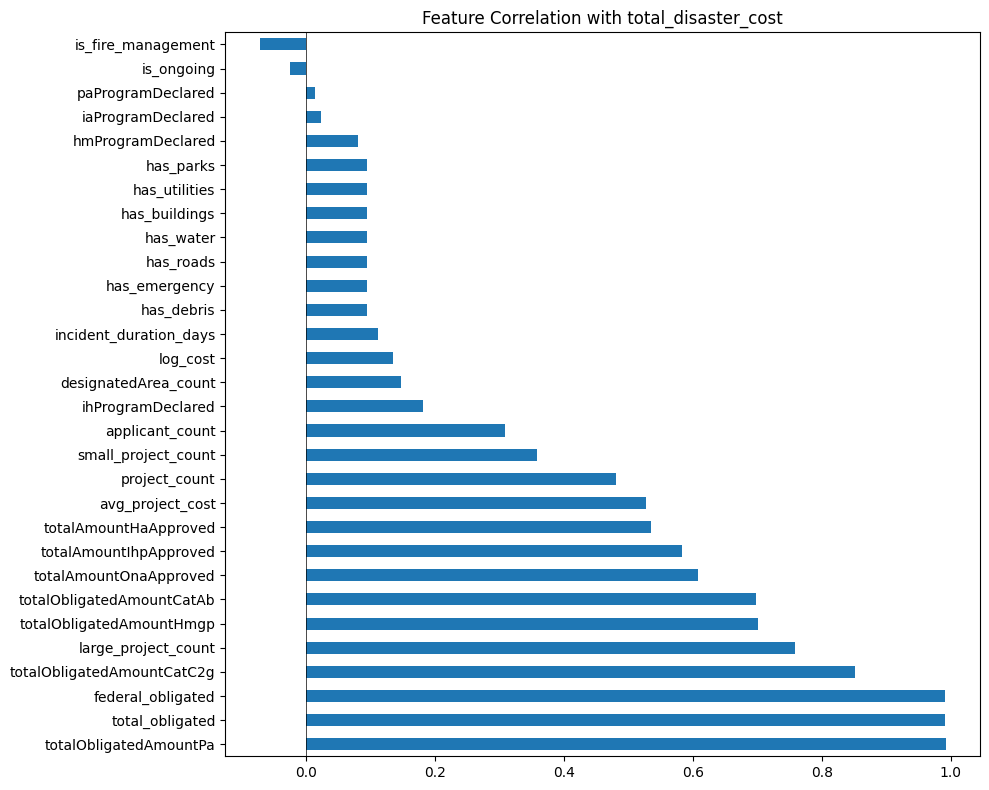

In [45]:
# Numeric columns only, excluding identifiers and dates
exclude_cols = ['disasterNumber', 'declarationDate', 'incidentBeginDate', 
                'incidentEndDate', 'fyDeclared']

numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Correlation with target specifically
target_corr = df[numeric_cols].corr()['total_disaster_cost'].drop('total_disaster_cost').sort_values(ascending=False)
print(target_corr)

# Visual
plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh')
plt.title('Feature Correlation with total_disaster_cost')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [46]:
# See how many records per group
group_counts = df.groupby(['incidentType', 'declarationType', 'state']).size()

print(f"Total combinations: {len(group_counts)}")
print(f"\nDistribution of group sizes:")
print(group_counts.describe())
print(f"\nGroups with only 1 record: {(group_counts == 1).sum()}")
print(f"Groups with fewer than 5 records: {(group_counts < 5).sum()}")

Total combinations: 703

Distribution of group sizes:
count    703.000000
mean       5.604552
std       18.071245
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max      261.000000
dtype: float64

Groups with only 1 record: 371
Groups with fewer than 5 records: 550


In [47]:
group_counts_2 = df.groupby(['incidentType', 'declarationType']).size()

print(f"Total combinations: {len(group_counts_2)}")
print(f"\nDistribution of group sizes:")
print(group_counts_2.describe())
print(f"\nGroups with only 1 record: {(group_counts_2 == 1).sum()}")
print(f"Groups with fewer than 5 records: {(group_counts_2 < 5).sum()}")

Total combinations: 45

Distribution of group sizes:
count      45.000000
mean       87.555556
std       272.071728
min         1.000000
25%         3.000000
50%        16.000000
75%        42.000000
max      1631.000000
dtype: float64

Groups with only 1 record: 6
Groups with fewer than 5 records: 14


In [48]:
sparse = df.groupby(['incidentType', 'declarationType']).size()
print(sparse[sparse < 5].sort_values())

incidentType         declarationType
Chemical             EM                 1
Fishing Losses       EM                 1
Mud/Landslide        EM                 1
Terrorist            DR                 1
                     EM                 1
Tropical Depression  DR                 1
Dam/Levee Break      DR                 2
                     EM                 2
Human Cause          EM                 2
Other                DR                 2
Volcanic Eruption    DR                 2
Earthquake           EM                 3
Tsunami              DR                 3
Typhoon              EM                 4
dtype: int64


## Feature Engineering (Encoding Historical Values)

In [14]:
cost_by_type = df.groupby(['incidentType', 'declarationType'])['total_disaster_cost'].median()
cost_fallback = df.groupby(['incidentType'])['total_disaster_cost'].median()

df['historical_median_cost'] = df.apply(
    lambda x: cost_by_type.get((x['incidentType'], x['declarationType'])), axis=1
)
mask = df['historical_median_cost'].isna()
df.loc[mask, 'historical_median_cost'] = df.loc[mask, 'incidentType'].map(cost_fallback)

In [15]:
project_by_state = df.groupby(['state', 'incidentType'])['project_count'].median()
project_fallback = df.groupby(['incidentType'])['project_count'].median()

df['historical_project_count'] = df.apply(
    lambda x: project_by_state.get((x['state'], x['incidentType'])), axis=1
)
mask = df['historical_project_count'].isna()
df.loc[mask, 'historical_project_count'] = df.loc[mask, 'incidentType'].map(project_fallback)


In [16]:
large_by_type = df.groupby(['incidentType', 'declarationType'])['large_project_count'].median()
large_fallback = df.groupby(['incidentType'])['large_project_count'].median()

df['historical_large_project_count'] = df.apply(
    lambda x: large_by_type.get((x['incidentType'], x['declarationType'])), axis=1
)
mask = df['historical_large_project_count'].isna()
df.loc[mask, 'historical_large_project_count'] = df.loc[mask, 'incidentType'].map(large_fallback)

In [17]:
print("Nulls in new features:")
print(df[['historical_median_cost', 'historical_project_count', 'historical_large_project_count']].isna().sum())

print("\nDistributions:")
print(df[['historical_median_cost', 'historical_project_count', 'historical_large_project_count']].describe())

Nulls in new features:
historical_median_cost            0
historical_project_count          0
historical_large_project_count    0
dtype: int64

Distributions:
       historical_median_cost  historical_project_count  \
count            3.940000e+03               3940.000000   
mean             1.387458e+07                 92.230964   
std              6.206482e+07                153.061721   
min              0.000000e+00                  0.000000   
25%              1.741553e+05                  0.000000   
50%              1.741553e+05                  4.250000   
75%              9.743419e+06                130.000000   
max              5.106794e+08               1927.500000   

       historical_large_project_count  
count                     3940.000000  
mean                         9.370305  
std                         15.264531  
min                          0.000000  
25%                          0.000000  
50%                          0.000000  
75%                         

historical_large_project_count    0.244104
historical_median_cost            0.222723
historical_project_count          0.072660
Name: total_disaster_cost, dtype: float64


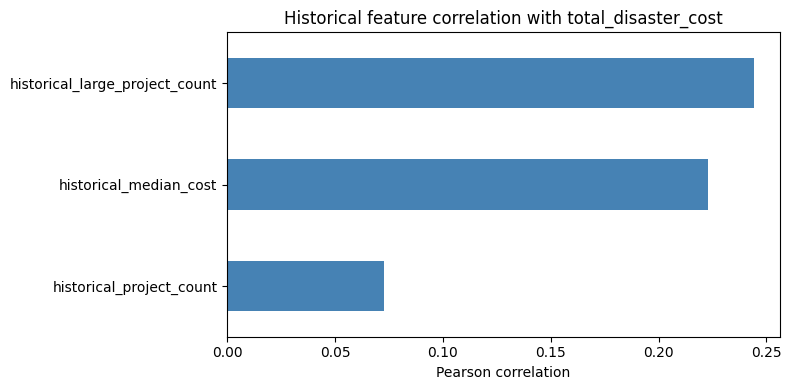

In [18]:
hist_features = [
    'historical_median_cost',
    'historical_project_count', 
    'historical_large_project_count'
]

corr = df[hist_features + ['total_disaster_cost']].corr()['total_disaster_cost'].drop('total_disaster_cost')
print(corr.sort_values(ascending=False))

# Visual

corr.sort_values().plot(kind='barh', figsize=(8, 4), color='steelblue')
plt.title('Historical feature correlation with total_disaster_cost')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

In [19]:
df['log_total_cost'] = np.log1p(df['total_disaster_cost'])

log_corr = df[hist_features + ['log_total_cost']].corr()['log_total_cost'].drop('log_total_cost')
print("\nCorrelation with LOG total_disaster_cost:")
print(log_corr.sort_values(ascending=False))


Correlation with LOG total_disaster_cost:
historical_large_project_count    0.488427
historical_project_count          0.292727
historical_median_cost            0.225218
Name: log_total_cost, dtype: float64


/Users/ransfordnyarko/Desktop/terranova-disaster-recovery/.terranova-dr/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Time Analysis EDA

### Overall Total Disaster Cost

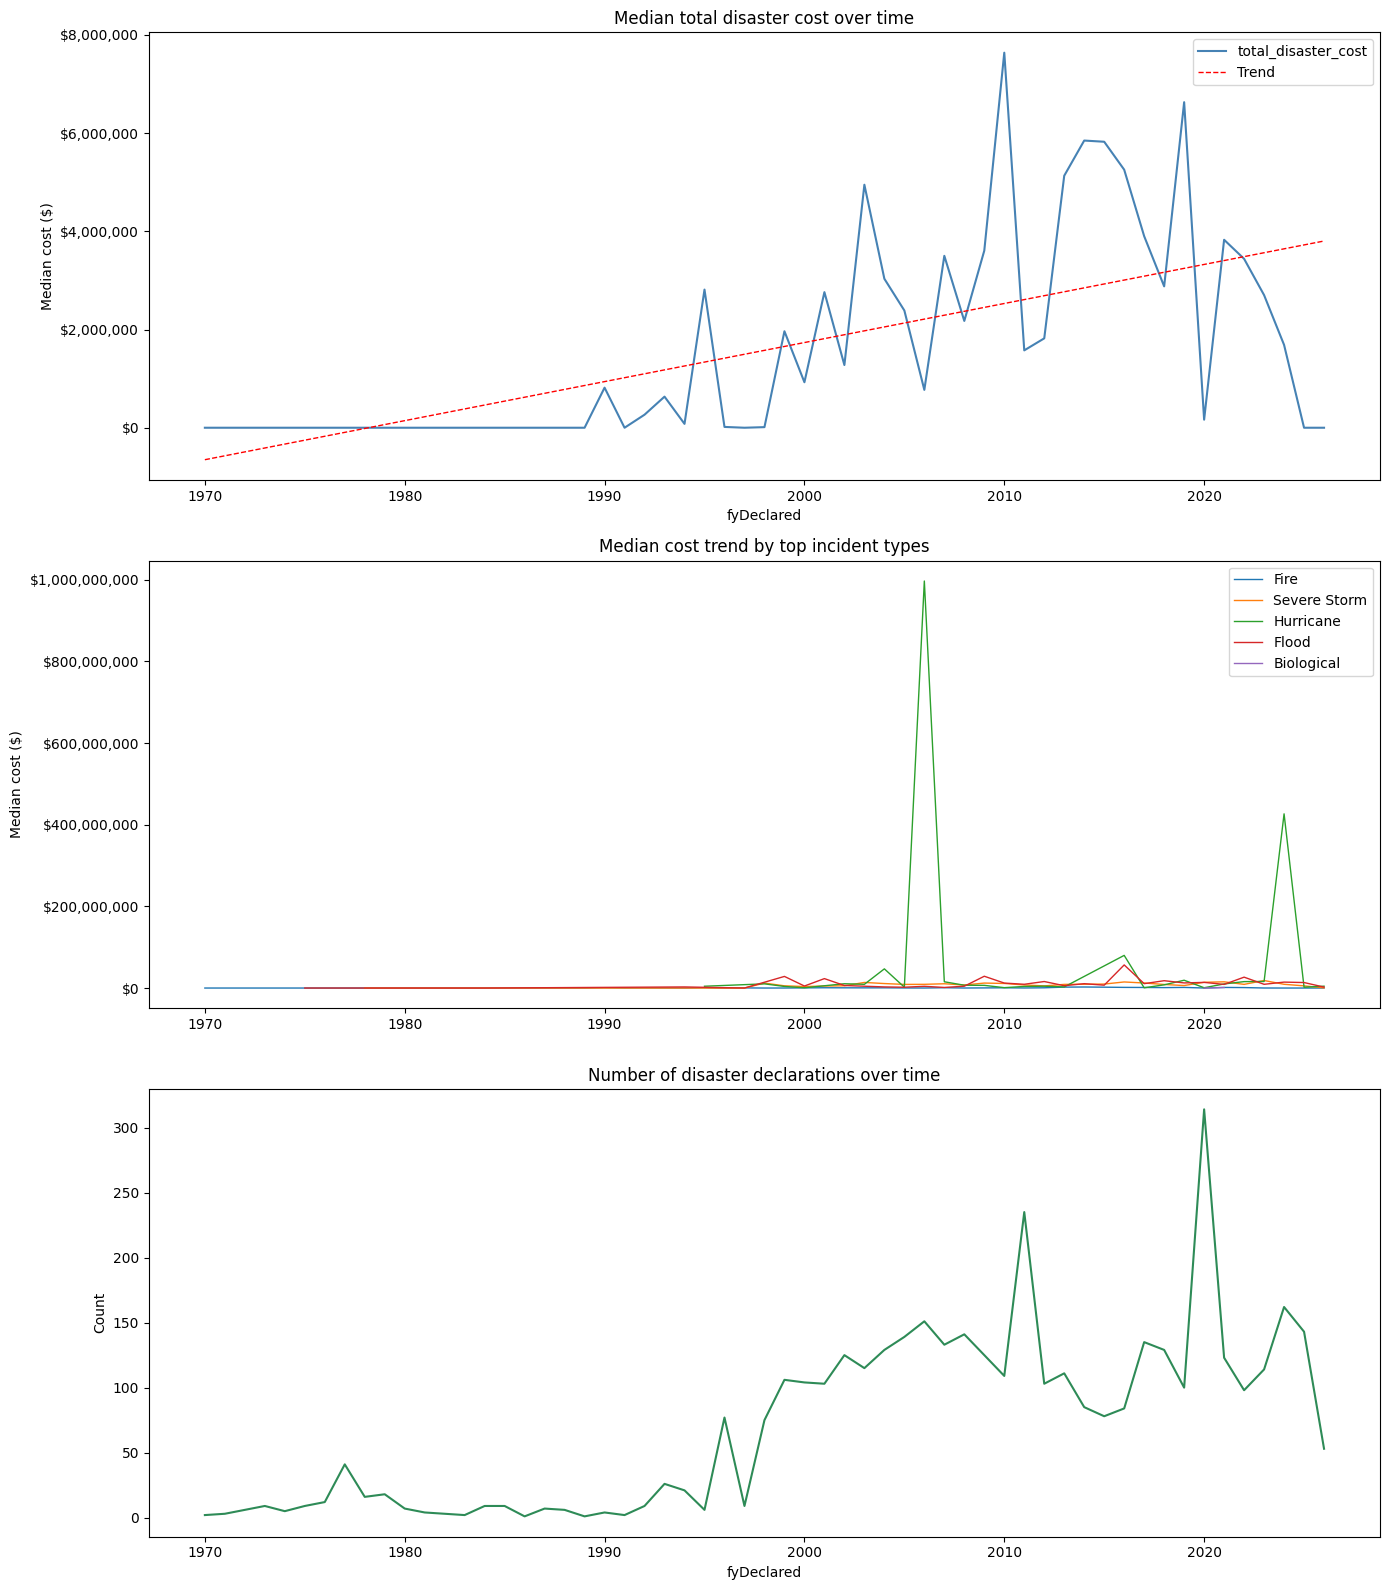

In [23]:
yearly_cost = df.groupby('fyDeclared')['total_disaster_cost'].median()

fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# 1. Overall median cost trend
yearly_cost.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Median total disaster cost over time')
axes[0].set_ylabel('Median cost ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

z = np.polyfit(yearly_cost.index, yearly_cost.values, 1)
p = np.poly1d(z)
axes[0].plot(yearly_cost.index, p(yearly_cost.index), 
             'r--', linewidth=1, label='Trend')
axes[0].legend()

top_types = df['incidentType'].value_counts().head(5).index
for incident in top_types:
    subset = df[df['incidentType'] == incident]
    yearly = subset.groupby('fyDeclared')['total_disaster_cost'].median()
    axes[1].plot(yearly.index, yearly.values, label=incident, linewidth=1)

axes[1].set_title('Median cost trend by top incident types')
axes[1].set_ylabel('Median cost ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()

disaster_count = df.groupby('fyDeclared').size()
disaster_count.plot(ax=axes[2], color='seagreen')
axes[2].set_title('Number of disaster declarations over time')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Granular Search

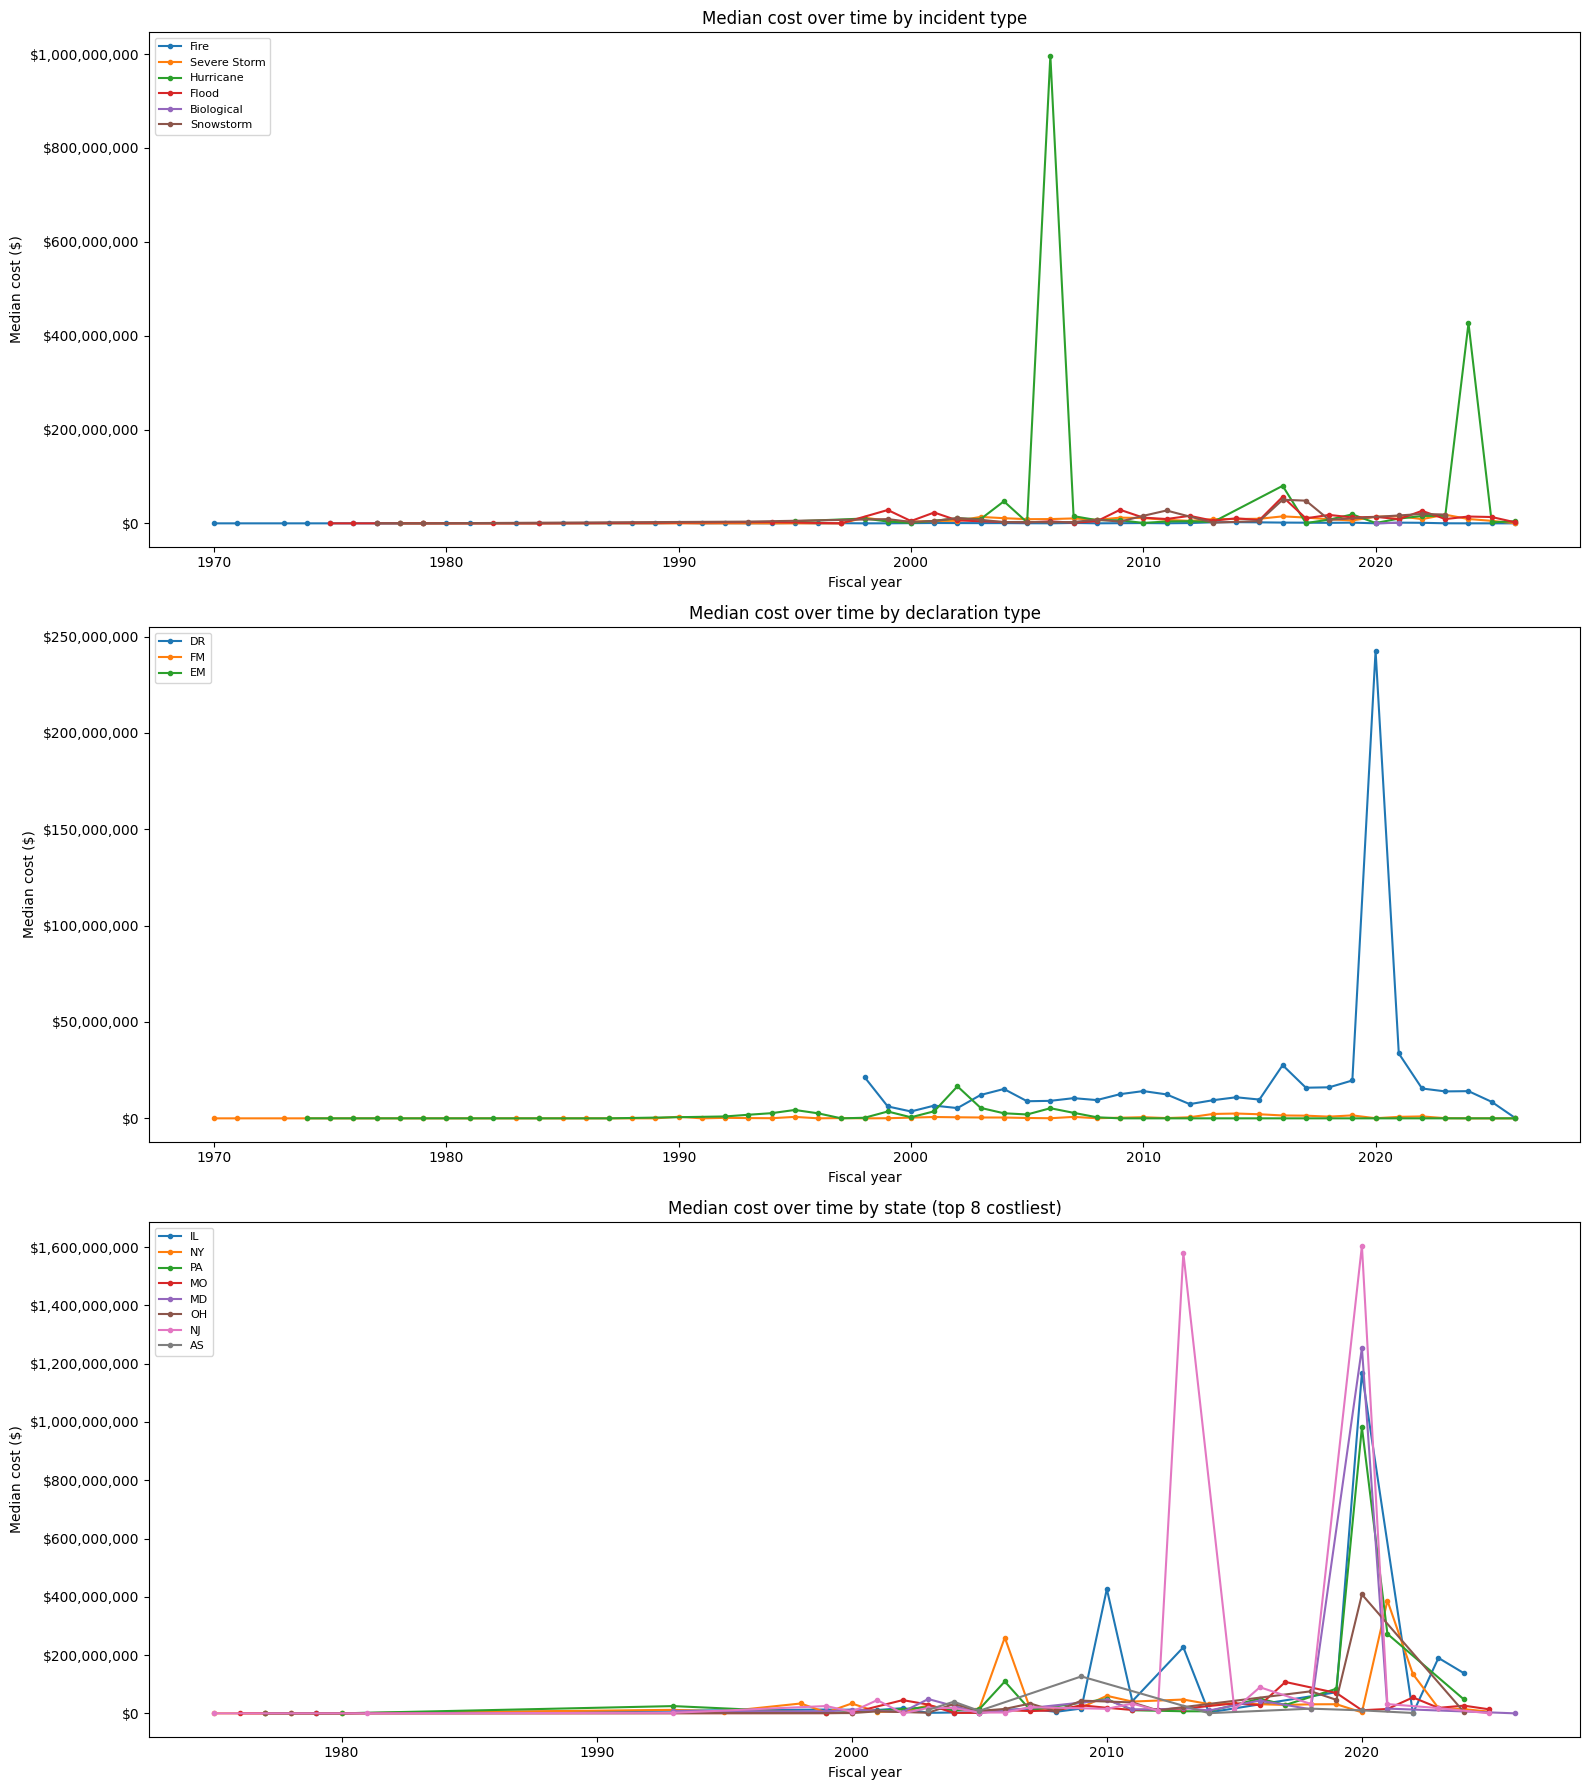

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))

# 1. Median cost trend by incidentType — top 6 for readability
top_types = df['incidentType'].value_counts().head(6).index
for incident in top_types:
    subset = df[df['incidentType'] == incident]
    yearly = subset.groupby('fyDeclared')['total_disaster_cost'].median()
    axes[0].plot(yearly.index, yearly.values, label=incident, linewidth=1.5, marker='o', markersize=3)

axes[0].set_title('Median cost over time by incident type')
axes[0].set_ylabel('Median cost ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(loc='upper left', fontsize=8)
axes[0].set_xlabel('Fiscal year')

# 2. Median cost trend by declarationType
for decl in df['declarationType'].unique():
    subset = df[df['declarationType'] == decl]
    yearly = subset.groupby('fyDeclared')['total_disaster_cost'].median()
    axes[1].plot(yearly.index, yearly.values, label=decl, linewidth=1.5, marker='o', markersize=3)

axes[1].set_title('Median cost over time by declaration type')
axes[1].set_ylabel('Median cost ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(loc='upper left', fontsize=8)
axes[1].set_xlabel('Fiscal year')

# 3. Median cost trend by state — top 8 costliest states for readability
top_states = df.groupby('state')['total_disaster_cost'].median().nlargest(8).index
for state in top_states:
    subset = df[df['state'] == state]
    yearly = subset.groupby('fyDeclared')['total_disaster_cost'].median()
    axes[2].plot(yearly.index, yearly.values, label=state, linewidth=1.5, marker='o', markersize=3)

axes[2].set_title('Median cost over time by state (top 8 costliest)')
axes[2].set_ylabel('Median cost ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[2].legend(loc='upper left', fontsize=8)
axes[2].set_xlabel('Fiscal year')

plt.tight_layout()
plt.show()

Overall month vs log cost correlation:
0.05936747008130712

Month vs log cost correlation by incidentType:
  Severe Storm: -0.039
  Hurricane: -0.023
  Mud/Landslide: 0.073
  Flood: -0.067
  Severe Ice Storm: 0.081
  Tornado: 0.112
  Snowstorm: 0.207
  Fire: 0.139
  Earthquake: -0.157
  Coastal Storm: 0.012
  Typhoon: -0.238
  Drought: -0.158
  Other: -0.121
  Biological: nan
  Tropical Storm: 0.049
  Winter Storm: 0.270


/Users/ransfordnyarko/Desktop/terranova-disaster-recovery/.terranova-dr/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/ransfordnyarko/Desktop/terranova-disaster-recovery/.terranova-dr/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


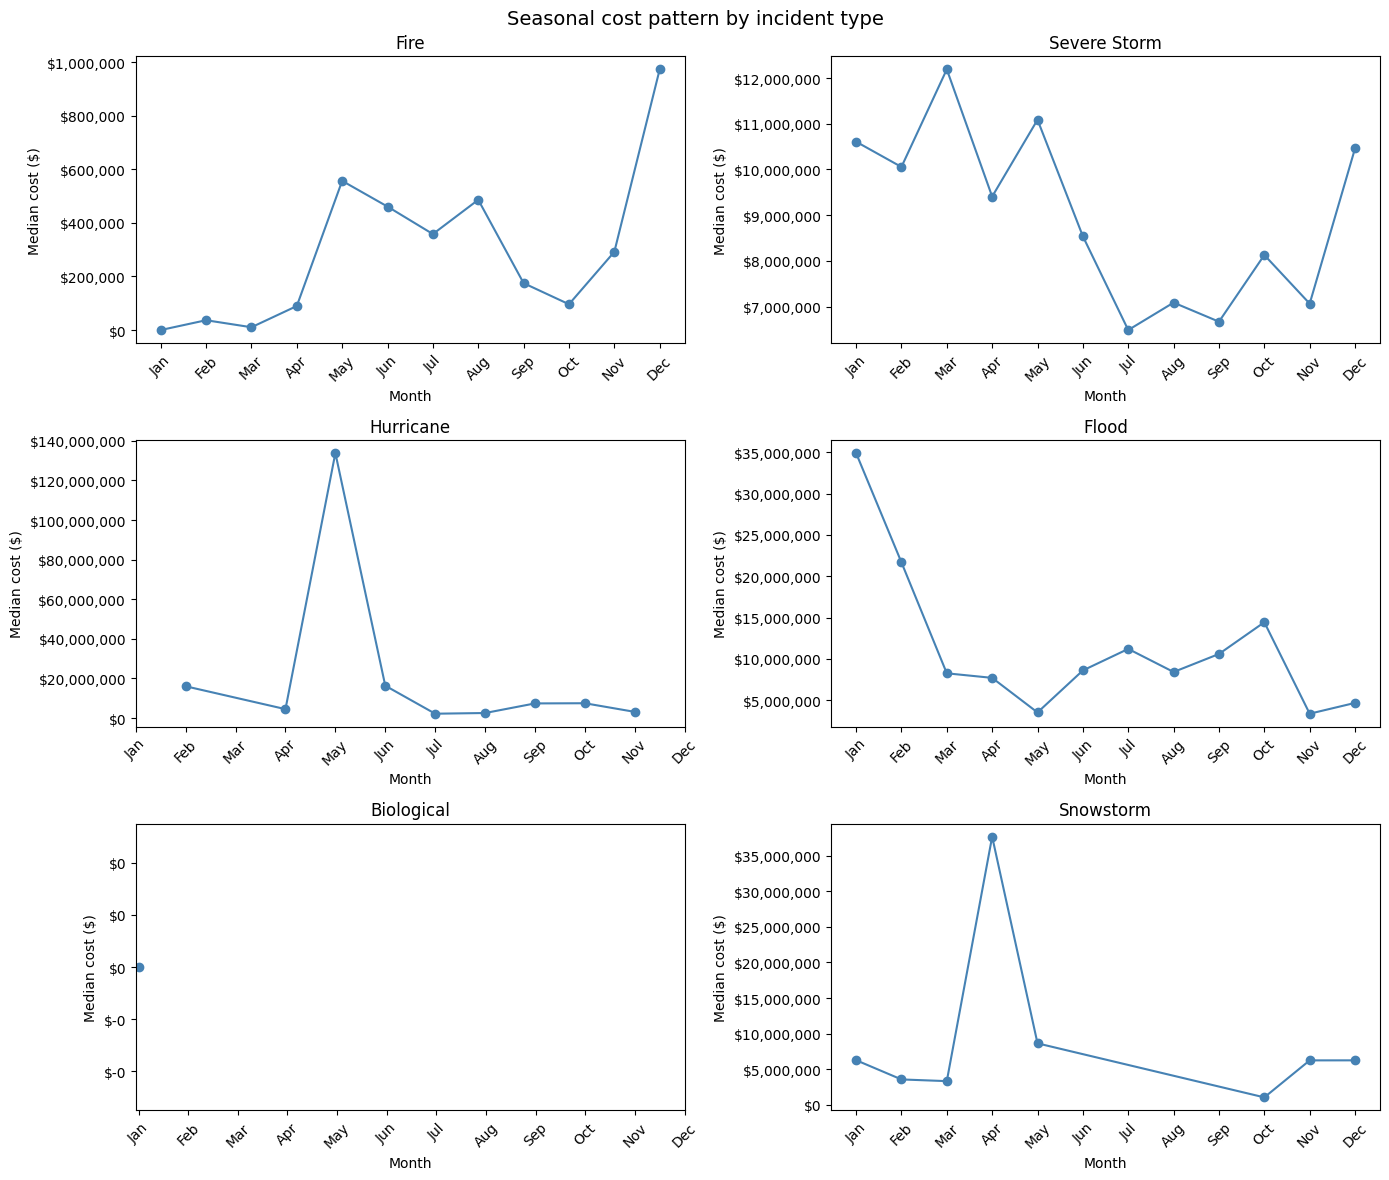

In [27]:
df['declaration_month'] = pd.to_datetime(df['incidentBeginDate']).dt.month
df['declaration_quarter'] = pd.to_datetime(df['incidentBeginDate']).dt.quarter

monthly = df.copy()
monthly['month'] = pd.to_datetime(monthly['incidentBeginDate']).dt.month

# Overall correlation
print("Overall month vs log cost correlation:")
print(df['declaration_month'].corr(df['log_total_cost']))

# Correlation by incidentType
print("\nMonth vs log cost correlation by incidentType:")
for incident in df['incidentType'].unique():
    subset = df[df['incidentType'] == incident]
    if len(subset) > 10:  # only meaningful if enough records
        corr = subset['declaration_month'].corr(subset['log_total_cost'])
        print(f"  {incident}: {corr:.3f}")

# Median cost by month per incidentType — top 6 for readability
top_types = df['incidentType'].value_counts().head(6).index

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, incident in enumerate(top_types):
    subset = monthly[monthly['incidentType'] == incident]
    monthly_cost = subset.groupby('month')['total_disaster_cost'].median()
    monthly_cost.plot(ax=axes[i], marker='o', color='steelblue', linewidth=1.5)
    axes[i].set_title(f'{incident}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Median cost ($)')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                              'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Seasonal cost pattern by incident type', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
winter_fires = df[
    (df['incidentType'] == 'Fire') & 
    (pd.to_datetime(df['incidentBeginDate']).dt.month.isin([12, 1, 2, 3]))
]
print(winter_fires['state'].value_counts().head(10))
print(f"\nMedian cost: ${winter_fires['total_disaster_cost'].median():,.0f}")

state
TX    105
OK     75
CA     19
KS     11
CO      6
NM      6
FL      6
HI      4
VA      3
SD      3
Name: count, dtype: int64

Median cost: $4,769


In [29]:
may_hurricanes = df[
    (df['incidentType'] == 'Hurricane') &
    (pd.to_datetime(df['incidentBeginDate']).dt.month == 5)
]
print(may_hurricanes[['disasterNumber', 'incidentBeginDate', 'state', 'total_disaster_cost']])

      disasterNumber         incidentBeginDate state  total_disaster_cost
3111            4715 2023-05-22 00:00:00+00:00    GU         1.338439e+08


In [30]:
# Break down fire cost by month AND state
fire_monthly = df[df['incidentType'] == 'Fire'].copy()
fire_monthly['month'] = pd.to_datetime(fire_monthly['incidentBeginDate']).dt.month

# How many fires per month?
print("Fire count by month:")
print(fire_monthly.groupby('month').size())

print("\nMedian cost by month:")
print(fire_monthly.groupby('month')['total_disaster_cost'].median())

print("\nMean cost by month (outlier sensitive):")
print(fire_monthly.groupby('month')['total_disaster_cost'].mean())

# The key question — what's driving December?
print("\nTop 5 most expensive December fires:")
dec_fires = fire_monthly[fire_monthly['month'] == 12]
print(dec_fires[['disasterNumber', 'state', 'incidentBeginDate', 
                  'total_disaster_cost']].sort_values(
    'total_disaster_cost', ascending=False).head(5))

Fire count by month:
month
1      46
2      45
3     138
4     137
5     107
6     249
7     285
8     328
9     208
10     86
11     59
12     23
dtype: int64

Median cost by month:
month
1          0.000
2      36654.850
3      10420.550
4      89674.220
5     556922.470
6     460929.860
7     358381.260
8     486273.135
9     175058.280
10     96285.070
11    292087.280
12    973316.290
Name: total_disaster_cost, dtype: float64

Mean cost by month (outlier sensitive):
month
1     4.648572e+06
2     5.158776e+05
3     2.713087e+05
4     3.821112e+06
5     1.803109e+06
6     3.395736e+06
7     5.426233e+06
8     7.623111e+06
9     3.234534e+07
10    1.418009e+07
11    4.088871e+07
12    1.860640e+07
Name: total_disaster_cost, dtype: float64

Top 5 most expensive December fires:
      disasterNumber state         incidentBeginDate  total_disaster_cost
2749            4353    CA 2017-12-04 00:00:00+00:00         3.264731e+08
3030            4634    CO 2021-12-30 00:00:00+00:00         5

In [31]:
df['fire_ca_flag'] = (
    (df['incidentType'] == 'Fire') & 
    (df['state'] == 'CA')
).astype(int)

# Check how much this explains
ca_fires = df[
    (df['incidentType'] == 'Fire') & 
    (df['state'] == 'CA')
]
non_ca_fires = df[
    (df['incidentType'] == 'Fire') & 
    (df['state'] != 'CA')
]

In [32]:
print("CA fires:")
print(ca_fires['total_disaster_cost'].describe())
print(f"\nNon-CA fires:")
print(non_ca_fires['total_disaster_cost'].describe())
print(f"\nCA fire count: {len(ca_fires)}")
print(f"Non-CA fire count: {len(non_ca_fires)}")

CA fires:
count    2.830000e+02
mean     2.641627e+07
std      1.502563e+08
min      0.000000e+00
25%      0.000000e+00
50%      1.591350e+06
75%      5.715281e+06
max      2.241643e+09
Name: total_disaster_cost, dtype: float64

Non-CA fires:
count    1.428000e+03
mean     6.439220e+06
std      1.356958e+08
min      0.000000e+00
25%      0.000000e+00
50%      1.398537e+05
75%      1.057944e+06
max      4.997195e+09
Name: total_disaster_cost, dtype: float64

CA fire count: 283
Non-CA fire count: 1428


In [33]:
# Historical median cost by incidentType + state
cost_by_state_incident = df.groupby(
    ['incidentType', 'state']
)['total_disaster_cost'].median()

# Fallback tiers
cost_by_incident = df.groupby(
    ['incidentType']
)['total_disaster_cost'].median()

# Apply with fallback
df['historical_cost_state_incident'] = df.apply(
    lambda x: cost_by_state_incident.get(
        (x['incidentType'], x['state'])
    ), axis=1
)

# Fill sparse combos with incidentType only median
mask = df['historical_cost_state_incident'].isna()
df.loc[mask, 'historical_cost_state_incident'] = (
    df.loc[mask, 'incidentType'].map(cost_by_incident)
)

# Check sparsity
state_incident_counts = df.groupby(['incidentType', 'state']).size()
print(f"Total combinations: {len(state_incident_counts)}")
print(f"Groups under 5 records: {(state_incident_counts < 5).sum()}")
print(f"Median group size: {state_incident_counts.median()}")

# Check correlation
print(f"\nCorrelation with log cost:")
print(df['historical_cost_state_incident'].corr(df['log_total_cost']))

Total combinations: 484
Groups under 5 records: 333
Median group size: 2.0

Correlation with log cost:
0.03570370152125381


In [34]:
# Drop the weak feature
df = df.drop(columns=['historical_cost_state_incident'])

# Confirm your final feature set
print("Final columns:")
print(df.columns.tolist())

print(f"\nFinal shape: {df.shape}")
print(f"\nAny remaining nulls:")
print(df.isna().sum()[df.isna().sum() > 0])



Final columns:
['disasterNumber', 'declarationDate', 'incidentType', 'declarationType', 'state', 'fyDeclared', 'incidentBeginDate', 'designatedArea_count', 'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared', 'hmProgramDeclared', 'incident_duration_days', 'is_ongoing', 'totalAmountIhpApproved', 'totalAmountHaApproved', 'totalAmountOnaApproved', 'totalObligatedAmountPa', 'totalObligatedAmountCatAb', 'totalObligatedAmountCatC2g', 'totalObligatedAmountHmgp', 'total_disaster_cost', 'total_obligated', 'federal_obligated', 'avg_project_cost', 'applicant_count', 'project_count', 'large_project_count', 'small_project_count', 'has_debris', 'has_emergency', 'has_roads', 'has_water', 'has_buildings', 'has_utilities', 'has_parks', 'historical_median_cost', 'historical_project_count', 'historical_large_project_count', 'log_total_cost', 'declaration_month', 'declaration_quarter', 'fire_ca_flag']

Final shape: (3940, 43)

Any remaining nulls:
log_total_cost    1
dtype: int64


Correlation with log total_disaster_cost:
historical_median_catc2g    0.465538
historical_median_hmgp      0.386898
historical_median_pa        0.211091
historical_median_catab     0.172837
historical_median_ihp       0.171552
historical_median_ona       0.155893
historical_median_ha        0.112523
Name: log_total_cost, dtype: float64


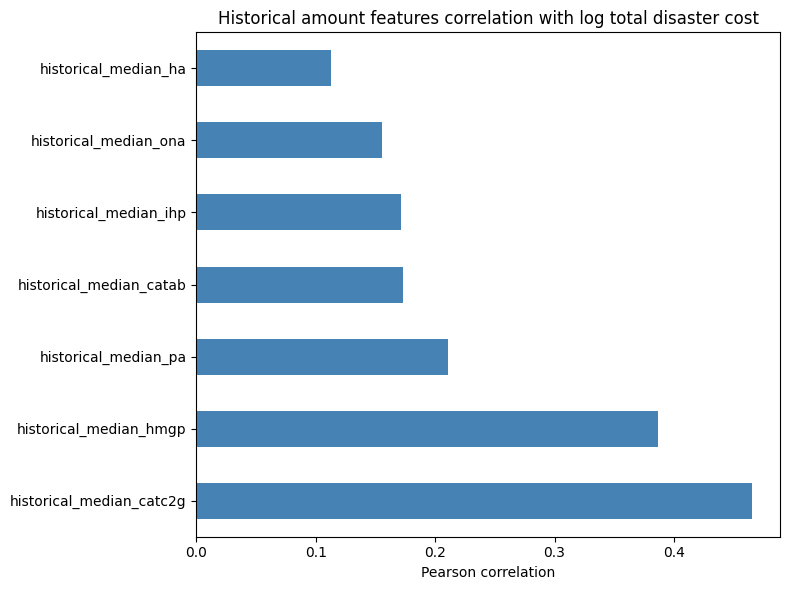


Weak features to drop (|corr| < 0.1): []
Strong features to keep: ['historical_median_catc2g', 'historical_median_hmgp', 'historical_median_pa', 'historical_median_catab', 'historical_median_ihp', 'historical_median_ona', 'historical_median_ha']


In [35]:
# Historical median of each cost component by incidentType + declarationType
cost_components = {
    'historical_median_ihp': 'totalAmountIhpApproved',
    'historical_median_ha': 'totalAmountHaApproved',
    'historical_median_ona': 'totalAmountOnaApproved',
    'historical_median_pa': 'totalObligatedAmountPa',
    'historical_median_hmgp': 'totalObligatedAmountHmgp',
    'historical_median_catab': 'totalObligatedAmountCatAb',
    'historical_median_catc2g': 'totalObligatedAmountCatC2g'
}

for new_col, source_col in cost_components.items():
    # Tier 1 — incidentType + declarationType
    tier1 = df.groupby(
        ['incidentType', 'declarationType']
    )[source_col].median()
    
    # Tier 2 — incidentType only fallback
    tier2 = df.groupby(['incidentType'])[source_col].median()
    
    df[new_col] = df.apply(
        lambda x: tier1.get((x['incidentType'], x['declarationType'])), axis=1
    )
    mask = df[new_col].isna()
    df.loc[mask, new_col] = (
        df.loc[mask, 'incidentType'].map(tier2)
    )

# Check correlations all at once
hist_amount_features = list(cost_components.keys())

print("Correlation with log total_disaster_cost:")
log_corr = df[hist_amount_features + ['log_total_cost']].corr(
)['log_total_cost'].drop('log_total_cost').sort_values(ascending=False)
print(log_corr)



log_corr.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Historical amount features correlation with log total disaster cost')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

# Drop anything below a threshold — say 0.1
weak = log_corr[abs(log_corr) < 0.1].index.tolist()
print(f"\nWeak features to drop (|corr| < 0.1): {weak}")

strong = log_corr[abs(log_corr) >= 0.1].index.tolist()
print(f"Strong features to keep: {strong}")

In [36]:
ENGINEERED_DATA_DIR = Path("__file__").resolve().parent.parent / "data" / "engineered"

In [37]:
# Save
df.to_csv(ENGINEERED_DATA_DIR / 'disaster_cost_model_ready.csv', index=False)
print("\nSaved successfully")


Saved successfully
